In [31]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from optimization_script import run_optimization
import stim
import random

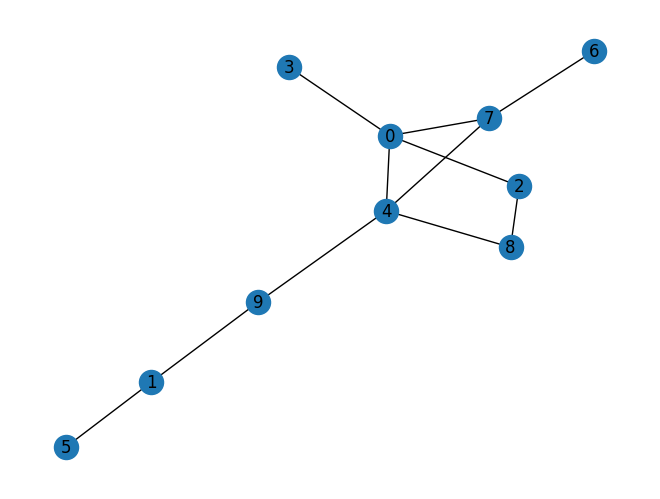

In [32]:
#use this function to generate connected erdos renyi graphs the default erdos renyi generator may produce disconnected graphs
def connected_erdos_renyi_graph(n, p, seed=None, max_tries=10000):
    """
    Generate a connected Erdős–Rényi random graph G(n, p).
    Retries until the generated graph is connected.

    Parameters
    ----------
    n : int
        Number of nodes.
    p : float
        Probability for edge creation.
    seed : int or None, optional
        Random seed for reproducibility.
    max_tries : int, optional
        Maximum number of attempts before giving up.

    Returns
    -------
    G : networkx.Graph
        A connected Erdős–Rényi graph.

    Raises
    ------
    RuntimeError
        If no connected graph is found after max_tries attempts.
    """
    rng = random.Random(seed)
    for _ in range(max_tries):
        # Generate a new random graph using a different seed each time
        current_seed = rng.randrange(1_000_000_000)
        G = nx.erdos_renyi_graph(n, p, seed=current_seed)
        if nx.is_connected(G):
            return G
    raise RuntimeError(f"Failed to generate a connected graph after {max_tries} attempts.")


G = connected_erdos_renyi_graph(10, 0.1, seed=42)
nx.draw(G, with_labels=True)


The netwrokx graph
#emmitters:  6
#emitter-CNOTs:  17
#gates-on-emitter:  59
Emission Order:  [28, 11, 17, 6, 21, 7, 25, 8, 5, 18, 26, 4, 27, 19, 15, 0, 22, 20, 13, 16, 29, 23, 9, 24, 14, 10, 2, 1, 3, 12]
Local Complementations Performed:  [21 28 23 16 18  5 17 13 15  4  6  1 23 28 16 18 17  5 15 21 13  3]


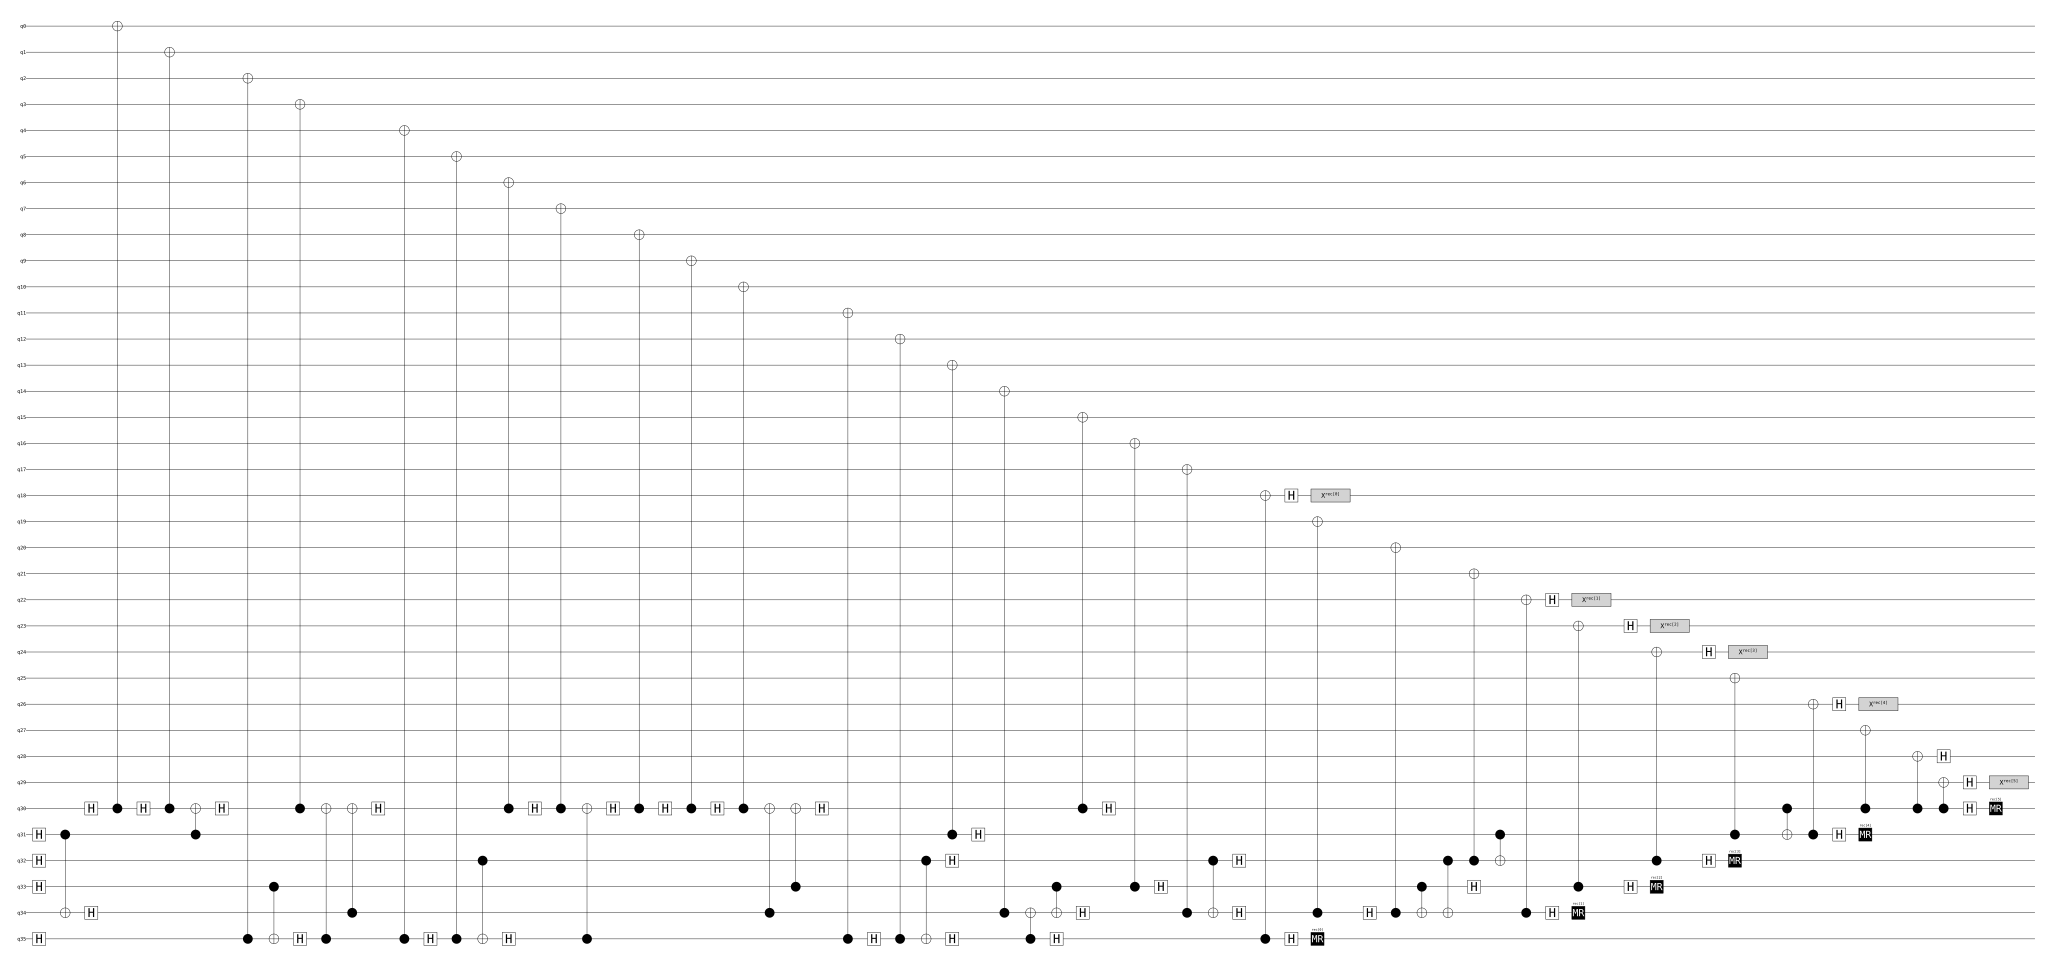

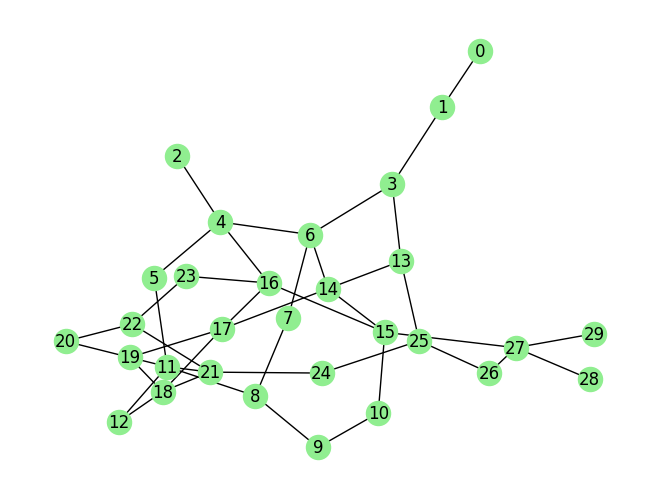

In [33]:
# Create a 4x4 grid graph
test_graph = connected_erdos_renyi_graph(30, 0.1, seed=42)


# Relabel the nodes to integers
test_graph = nx.relabel_nodes(test_graph, {node: i for i, node in enumerate(test_graph.nodes())})

# Run the optimization scheme on the grid graph
opt_graph, circuit, stats = run_optimization(test_graph)
print(f"The netwrokx graph")
nx.draw(opt_graph, with_labels=True, node_color='lightgreen')
# print("Statistics: ", stats)
print("#emmitters: ", stats[0])
print("#emitter-CNOTs: ", stats[1])
print("#gates-on-emitter: ", stats[2])
print("Emission Order: ", stats[3])
print("Local Complementations Performed: ", stats[4])
circuit.diagram('timeline-svg')

In [220]:
np.linspace(0.1,0.95, 20)

array([0.1       , 0.14473684, 0.18947368, 0.23421053, 0.27894737,
       0.32368421, 0.36842105, 0.41315789, 0.45789474, 0.50263158,
       0.54736842, 0.59210526, 0.63684211, 0.68157895, 0.72631579,
       0.77105263, 0.81578947, 0.86052632, 0.90526316, 0.95      ])

In [221]:
# Create the samples for different probabilities
n = 30
num_samples = 25
probabilities = np.linspace(0.1,0.95, 20) #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6 , 0.7, 0.8 ,0.82, 0.85, 0.9, 0.92,0.95 ]  
seed = 42

# Dictionary to store graphs for each p
graphs_by_p = {}

for p in probabilities:
    print(f"Generating {num_samples} connected graphs for p={p}")
    graphs_by_p[p] = [connected_erdos_renyi_graph(n, p, seed + i) for i in range(num_samples)]

print("\nDone! Summary:")
for p, graphs in graphs_by_p.items():
    print(f"p = {p:.1f} → {len(graphs)} connected graphs")

Generating 25 connected graphs for p=0.1
Generating 25 connected graphs for p=0.14473684210526316
Generating 25 connected graphs for p=0.18947368421052632
Generating 25 connected graphs for p=0.23421052631578948
Generating 25 connected graphs for p=0.2789473684210526
Generating 25 connected graphs for p=0.3236842105263158
Generating 25 connected graphs for p=0.368421052631579
Generating 25 connected graphs for p=0.41315789473684206
Generating 25 connected graphs for p=0.45789473684210524
Generating 25 connected graphs for p=0.5026315789473684
Generating 25 connected graphs for p=0.5473684210526316
Generating 25 connected graphs for p=0.5921052631578947
Generating 25 connected graphs for p=0.6368421052631579
Generating 25 connected graphs for p=0.6815789473684211
Generating 25 connected graphs for p=0.7263157894736841
Generating 25 connected graphs for p=0.7710526315789473
Generating 25 connected graphs for p=0.8157894736842105
Generating 25 connected graphs for p=0.8605263157894737
Gen

In [222]:
# New dictionary to store the reduced-edge graphs
reduced_graphs_by_p_with_edge_reduction = {}

for p, graph_list in graphs_by_p.items():
    print(f"Processing graphs for p={p}...")
    reduced_graphs = [run_optimization(G) for G in graph_list]
    reduced_graphs_by_p_with_edge_reduction[p] = reduced_graphs

print("All graphs processed and stored in reduced_graphs_by_p.")

Processing graphs for p=0.1...


/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/lib/generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


Processing graphs for p=0.14473684210526316...
Processing graphs for p=0.18947368421052632...
Processing graphs for p=0.23421052631578948...
Processing graphs for p=0.2789473684210526...
Processing graphs for p=0.3236842105263158...
Processing graphs for p=0.368421052631579...
Processing graphs for p=0.41315789473684206...
Processing graphs for p=0.45789473684210524...
Processing graphs for p=0.5026315789473684...
Processing graphs for p=0.5473684210526316...
Processing graphs for p=0.5921052631578947...
Processing graphs for p=0.6368421052631579...
Processing graphs for p=0.6815789473684211...
Processing graphs for p=0.7263157894736841...
Processing graphs for p=0.7710526315789473...
Processing graphs for p=0.8157894736842105...
Processing graphs for p=0.8605263157894737...
Processing graphs for p=0.9052631578947369...
Processing graphs for p=0.95...
All graphs processed and stored in reduced_graphs_by_p.


In [223]:
# New dictionary to store the reduced-edge graphs
reduced_graphs_by_p_no_edge_reduction = {}

for p, graph_list in graphs_by_p.items():
    print(f"Processing graphs for p={p}...")
    reduced_graphs = [run_optimization(G, edge_reduction=False) for G in graph_list]
    reduced_graphs_by_p_no_edge_reduction[p] = reduced_graphs

print("All graphs processed and stored in reduced_graphs_by_p.")

Processing graphs for p=0.1...
Processing graphs for p=0.14473684210526316...
Processing graphs for p=0.18947368421052632...
Processing graphs for p=0.23421052631578948...
Processing graphs for p=0.2789473684210526...
Processing graphs for p=0.3236842105263158...
Processing graphs for p=0.368421052631579...
Processing graphs for p=0.41315789473684206...
Processing graphs for p=0.45789473684210524...
Processing graphs for p=0.5026315789473684...
Processing graphs for p=0.5473684210526316...
Processing graphs for p=0.5921052631578947...
Processing graphs for p=0.6368421052631579...
Processing graphs for p=0.6815789473684211...
Processing graphs for p=0.7263157894736841...
Processing graphs for p=0.7710526315789473...
Processing graphs for p=0.8157894736842105...
Processing graphs for p=0.8605263157894737...
Processing graphs for p=0.9052631578947369...
Processing graphs for p=0.95...
All graphs processed and stored in reduced_graphs_by_p.


In [224]:
reduced_graphs_by_p_no_edge_reduction

{np.float64(0.1): [(<networkx.classes.graph.Graph at 0x1473b6dd0>,
   stim.Circuit('''
       H 35 34 33 31 30
       CX 34 0 33 34
       H 34
       CX 34 1
       H 1
       CX 34 2
       H 34
       CX 34 3 30 34
       H 34
       CX 34 4
       H 34
       CX 34 5
       H 34
       CX 35 6 34 35 32 35
       H 35 32
       CX 34 7 31 34
       H 34
       CX 32 8 35 32
       H 35
       S 35
       CX 34 9 35 34
       H 35
       S 35
       H 34
       CX 34 10
       X 34
       CX 35 34 32 34
       H 35
       S 35
       H 34
       S 34
       CX 35 11
       H 11 35
       MR 35
       CX rec[-1] 11 32 12
       H 32
       CX 34 13 33 34 31 34 31 14 34 31 30 31
       H 34 31
       CX 34 15 32 34
       H 34 32
       CX 33 16
       H 33
       CX 31 17 34 31
       H 31
       CX 30 18 31 30
       H 30
       CX 32 19
       H 19
       CX 34 32
       H 32
       CX 34 20 34 21
       H 21 34
       MR 34
       CX rec[-1] 21 33 22 32 33 33 23
       H 23 33
    

In [225]:
num_samples = 25
num_samples

25

In [226]:
#first the p=0.1
#then choose a graph (0-9)
# for stats pick 2


# reduced_graphs_by_p_with_edge_reduction[0.1][num_samples-1][2][0]
# reduced_graphs_by_p_no_edge_reduction[0.1][3][2][0]
# num_samples = 25

emitters_no_edge_reduction = {}

for prob in probabilities:
    test_array = []
    for i in range(num_samples):
        emitters = reduced_graphs_by_p_no_edge_reduction[prob][i-1][2][0]
        # print("Emitters:", emitters)
        test_array.append(emitters)
        
    # print(np.mean(test_array))
    mean = np.mean(test_array)
    # print(np.std(test_array))
    std = np.std(test_array)
    emitters_no_edge_reduction[prob] = {"mean": mean, "std": std} 

In [227]:
emitters_no_edge_reduction

{np.float64(0.1): {'mean': np.float64(5.76),
  'std': np.float64(1.3047605144240073)},
 np.float64(0.14473684210526316): {'mean': np.float64(8.24),
  'std': np.float64(1.3047605144240073)},
 np.float64(0.18947368421052632): {'mean': np.float64(10.08),
  'std': np.float64(1.0552724766618335)},
 np.float64(0.23421052631578948): {'mean': np.float64(11.44),
  'std': np.float64(1.0229369482035537)},
 np.float64(0.2789473684210526): {'mean': np.float64(12.56),
  'std': np.float64(0.6974238309665077)},
 np.float64(0.3236842105263158): {'mean': np.float64(13.12),
  'std': np.float64(0.5878775382679627)},
 np.float64(0.368421052631579): {'mean': np.float64(13.28),
  'std': np.float64(0.6013318551349164)},
 np.float64(0.41315789473684206): {'mean': np.float64(13.6),
  'std': np.float64(0.4898979485566356)},
 np.float64(0.45789473684210524): {'mean': np.float64(13.64),
  'std': np.float64(0.48000000000000004)},
 np.float64(0.5026315789473684): {'mean': np.float64(13.76),
  'std': np.float64(0.427

In [228]:
#get the emitters for each p with edge reduction

emitters_with_edge_reduction = {}
num_samples = 25

for prob in probabilities:
    # print(f"Processing graphs for p={prob}...")
    # emitters_with_edge_reduction[prob] = []
    inter_array = []
    for num_samples in range(num_samples):
        # print("Emitters:",reduced_graphs_by_p_with_edge_reduction[prob][num_samples-1][2][0])
        inter_array.append(reduced_graphs_by_p_with_edge_reduction[prob][num_samples-1][2][0])
    mean = np.mean(inter_array)
    std = np.std(inter_array)
    emitters_with_edge_reduction[prob] = {"mean": mean, "std": std} 


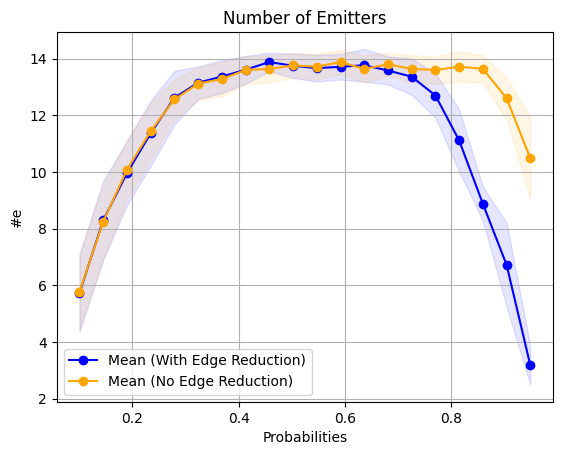

In [229]:
# Plotting emitters_with_edge_reduction
ps = sorted(emitters_with_edge_reduction.keys())
mean_edges_with_edge_reduction = [value['mean'] for value in emitters_with_edge_reduction.values()]
std_edges_with_edge_reduction = [value['std'] for value in emitters_with_edge_reduction.values()]

plt.plot(ps, mean_edges_with_edge_reduction, marker='o', linestyle='-', color='blue', label='Mean (With Edge Reduction)')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_edges_with_edge_reduction, std_edges_with_edge_reduction)],
    [m + s for m, s in zip(mean_edges_with_edge_reduction, std_edges_with_edge_reduction)],
    color='blue', alpha=0.1
)

# Plotting emitters_no_edge_reduction
ps = sorted(emitters_no_edge_reduction.keys())
mean_edges_no_edge_reduction = [value['mean'] for value in emitters_no_edge_reduction.values()]
std_edges_no_edge_reduction = [value['std'] for value in emitters_no_edge_reduction.values()]

plt.plot(ps, mean_edges_no_edge_reduction, marker='o', linestyle='-', color='orange', label='Mean (No Edge Reduction)')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_edges_no_edge_reduction, std_edges_no_edge_reduction)],
    [m + s for m, s in zip(mean_edges_no_edge_reduction, std_edges_no_edge_reduction)],
    color='orange', alpha=0.1
)

plt.xlabel('Probabilities')
plt.ylabel('#e')
plt.grid()
plt.title('Number of Emitters')
plt.legend()
plt.show()

In [230]:
#get the emitters for each p with edge reduction

cnots_with_edge_reduction = {}
num_samples = 25

for prob in probabilities:
    print(f"Processing graphs for p={prob}...")
    # cnots_with_edge_reduction[prob] = []
    inter_array = []
    for num_samples in range(num_samples):
        # print("Emitters:",reduced_graphs_by_p_with_edge_reduction[prob][num_samples-1][2][0])
        inter_array.append(reduced_graphs_by_p_with_edge_reduction[prob][num_samples-1][2][1])
    mean = np.mean(inter_array)
    std = np.std(inter_array)
    cnots_with_edge_reduction[prob] = {"mean": mean, "std": std} 


# no edge reduction
cnots_no_edge_reduction = {}

num_samples = 25
for prob in probabilities:
    print(f"Processing graphs for p={prob}...")
    # cnots_no_edge_reduction[prob] = []
    inter_array = []
    for num_samples in range(num_samples):
        # print("Emitters:",reduced_graphs_by_p_with_edge_reduction[prob][num_samples-1][2][0])
        inter_array.append(reduced_graphs_by_p_no_edge_reduction[prob][num_samples-1][2][1])
    mean = np.mean(inter_array)
    std = np.std(inter_array)
    cnots_no_edge_reduction[prob] = {"mean": mean, "std": std} 

cnots_no_edge_reduction

Processing graphs for p=0.1...
Processing graphs for p=0.14473684210526316...
Processing graphs for p=0.18947368421052632...
Processing graphs for p=0.23421052631578948...
Processing graphs for p=0.2789473684210526...
Processing graphs for p=0.3236842105263158...
Processing graphs for p=0.368421052631579...
Processing graphs for p=0.41315789473684206...
Processing graphs for p=0.45789473684210524...
Processing graphs for p=0.5026315789473684...
Processing graphs for p=0.5473684210526316...
Processing graphs for p=0.5921052631578947...
Processing graphs for p=0.6368421052631579...
Processing graphs for p=0.6815789473684211...
Processing graphs for p=0.7263157894736841...
Processing graphs for p=0.7710526315789473...
Processing graphs for p=0.8157894736842105...
Processing graphs for p=0.8605263157894737...
Processing graphs for p=0.9052631578947369...
Processing graphs for p=0.95...
Processing graphs for p=0.1...
Processing graphs for p=0.14473684210526316...
Processing graphs for p=0.1

{np.float64(0.1): {'mean': np.float64(28.48),
  'std': np.float64(14.77056532431985)},
 np.float64(0.14473684210526316): {'mean': np.float64(58.625),
  'std': np.float64(16.562539308129455)},
 np.float64(0.18947368421052632): {'mean': np.float64(83.04347826086956),
  'std': np.float64(13.440620653596143)},
 np.float64(0.23421052631578948): {'mean': np.float64(113.36363636363636),
  'std': np.float64(19.944344047978422)},
 np.float64(0.2789473684210526): {'mean': np.float64(137.57142857142858),
  'std': np.float64(11.474906073156117)},
 np.float64(0.3236842105263158): {'mean': np.float64(158.2),
  'std': np.float64(13.880201727640705)},
 np.float64(0.368421052631579): {'mean': np.float64(163.68421052631578),
  'std': np.float64(15.83817052027673)},
 np.float64(0.41315789473684206): {'mean': np.float64(170.61111111111111),
  'std': np.float64(9.843999237487493)},
 np.float64(0.45789473684210524): {'mean': np.float64(178.2941176470588),
  'std': np.float64(10.93168468735749)},
 np.float64

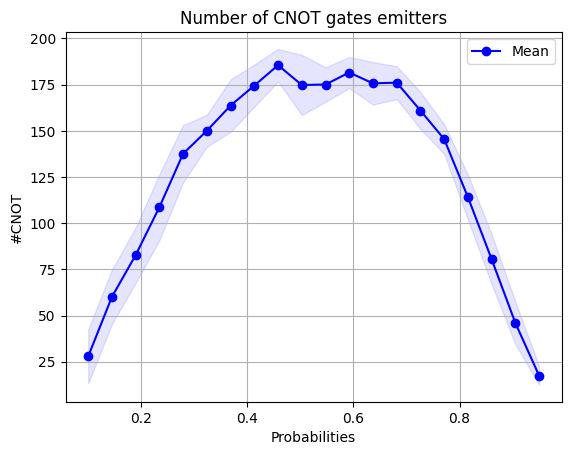

In [231]:
ps = sorted(cnots_with_edge_reduction.keys())
mean_cnots = [value['mean'] for value in cnots_with_edge_reduction.values()]
std_cnots = [value['std'] for value in cnots_with_edge_reduction.values()]

plt.plot(ps, mean_cnots, marker='o', linestyle='-', color='blue', label='Mean')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_cnots, std_cnots)],
    [m + s for m, s in zip(mean_cnots, std_cnots)],
    color='blue', alpha=0.1
)
plt.xlabel('Probabilities')
plt.ylabel('#CNOT')
plt.grid()
plt.title('Number of CNOT gates emitters')
plt.legend()
plt.show()

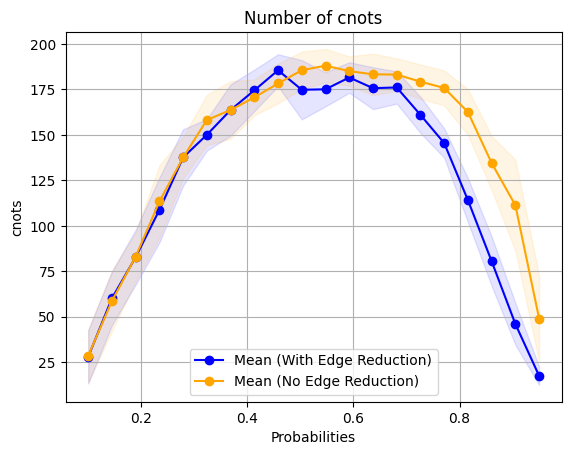

In [232]:
# Plotting cnots_with_edge_reduction
ps = sorted(cnots_with_edge_reduction.keys())
mean_cnots_with_edge_reduction = [value['mean'] for value in cnots_with_edge_reduction.values()]
std_cnots_with_edge_reduction = [value['std'] for value in cnots_with_edge_reduction.values()]

plt.plot(ps, mean_cnots_with_edge_reduction, marker='o', linestyle='-', color='blue', label='Mean (With Edge Reduction)')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_cnots_with_edge_reduction, std_cnots_with_edge_reduction)],
    [m + s for m, s in zip(mean_cnots_with_edge_reduction, std_cnots_with_edge_reduction)],
    color='blue', alpha=0.1
)

# Plotting cnots_no_edge_reduction
ps = sorted(cnots_no_edge_reduction.keys())
mean_cnots_no_edge_reduction = [value['mean'] for value in cnots_no_edge_reduction.values()]
std_cnots_no_edge_reduction = [value['std'] for value in cnots_no_edge_reduction.values()]

plt.plot(ps, mean_cnots_no_edge_reduction, marker='o', linestyle='-', color='orange', label='Mean (No Edge Reduction)')
plt.fill_between(
    ps,
    [m - s for m, s in zip(mean_cnots_no_edge_reduction, std_cnots_no_edge_reduction)],
    [m + s for m, s in zip(mean_cnots_no_edge_reduction, std_cnots_no_edge_reduction)],
    color='orange', alpha=0.1
)

plt.xlabel('Probabilities')
plt.ylabel('cnots')
plt.grid()
plt.title('Number of cnots')
plt.legend()
plt.show()